In [ ]:
!pip install -U unsloth unsloth_zoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/216.

In [ ]:
# needed as this function doesn't like it when the lm_head has its size changed
from unsloth import tokenizer_utils
def do_nothing(*args, **kwargs):
    pass
tokenizer_utils.fix_untrained_tokens = do_nothing

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## 1. Load Qwen

The Unsloth classification approach is used as the starting point for the Qwen experiment. Qwen is loaded as a base language model and will be fine-tuned primarily to predict acute kidney rejection from transplant assessment data.

The prediction task is binary:

- **Class 0:** no acute rejection within 30 days
- **Class 1:** acute rejection within 30 days

Therefore, `NUM_CLASSES` is set to 2 for the classification task.

Alongside classification, a smaller factual-recall task will also be included during training. This allows the same model to be evaluated on whether it retains information about individual recipients in its training data.

In [ ]:
import os
import warnings
from typing import Any, Dict, List, Tuple, Union

import torch
import pandas as pd
import numpy as np
import datasets
import matplotlib.pyplot as plt

from datasets import load_dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig
from transformers import (
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)
from sklearn.model_selection import train_test_split


# Check the available CUDA GPU
major_version, minor_version = torch.cuda.get_device_capability()
print(f"Major: {major_version}, Minor: {minor_version}")


# The rejection-prediction task has two classes.
# Qwen itself keeps its full vocabulary because it will also
# be trained to recall factual recipient information.
NUM_CLASSES = 2

max_seq_length = 2048

# Allow Unsloth/PyTorch to select the appropriate precision
# for the available GPU.
dtype = None

# Follow the supplied Unsloth Qwen classification implementation.
model_name = "unsloth/Qwen3-4B-Base"
load_in_4bit = False


model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_name,
    load_in_4bit=load_in_4bit,
    max_seq_length=max_seq_length,
    dtype=dtype,
)

print("Loaded model:", model_name)

Major: 7, Minor: 5
==((====))==  Unsloth 2026.9.2: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loaded model: unsloth/Qwen3-4B-Base


## 2. Add LoRA Fine-Tuning

LoRA is used to efficiently adapt Qwen to the kidney transplant data without updating all parameters in the base model.

The model is trained primarily to predict acute rejection from clinical assessments. A smaller factual-recall task is included in the same training dataset so that retention of information about individual training recipients can also be evaluated.

Qwen's full output vocabulary is retained so that the same model can produce both binary classification answers and factual text responses.

In [ ]:
from peft import LoftQConfig

model = FastLanguageModel.get_peft_model(
    model,

    r = 16,

    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],

    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = True,
)

print(
    "trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)

Unsloth 2026.9.2 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


trainable parameters: 33030144


## 3. Load the Kidney Transplant Dataset

The original example notebook uses a financial sentiment dataset containing `text` and `label` columns. This experiment instead uses the synthetic kidney transplant dataset developed for this project.

Three project artefacts are loaded:

- the kidney transplant assessment dataset used for prediction;
- the previously established train, validation and test split assignments;
- the synthetic identity table, which provides recipient-level details for the factual-recall task.

The existing split assignments are reused so that the Qwen experiment remains consistent with the earlier experiments.

In [ ]:
data_path = "/content/qub-machine-unlearning/code/final_submission/data/final/kidney_transplant_assessments.csv"
split_path = "/content/qub-machine-unlearning/code/final_submission/processed_data/split_assignments.csv"
identity_path = "/content/qub-machine-unlearning/code/final_submission/data/final/kidney_transplant_identity.csv"

data = pd.read_csv(data_path)
split_assignments = pd.read_csv(split_path)
identity = pd.read_csv(identity_path)

print("Assessments:", data.shape)
print("Split assignments:", split_assignments.shape)
print("Identity:", identity.shape)

Assessments: (60000, 31)
Split assignments: (10000, 6)
Identity: (18000, 12)


## 4. Reuse the Existing Data Splits

The dataset is not randomly split again.

The same frozen training, validation and test assignments used throughout the project are reused. This keeps the Qwen experiment consistent with the earlier experiments and ensures that differences in results are not caused by different data splits.

In [ ]:
data = data.merge(
    split_assignments[["recipient_id", "donor_id", "split"]],
    on=["recipient_id", "donor_id"],
    how="left",
    validate="many_to_one",
)

train_df = data[data["split"] == "train"].copy()
val_df = data[data["split"] == "validation"].copy()
test_df = data[data["split"] == "test"].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 42024
Validation: 8988
Test: 8988


### 4.1 Add Recipient Identity Information to the Training Data

Recipient identity information is required for the factual-recall part of the experiment.

The recipient identifier in the assessment dataset is matched to the corresponding recipient record in the identity table. Identity information is added only to the training data at this stage, ensuring that the factual-recall task is created only from recipients that the model is allowed to see during training.

The clinical prediction features remain unchanged.

In [ ]:
recipient_identity = identity[
    identity["person_role"].eq("Recipient")
].copy()

recipient_identity = recipient_identity.rename(
    columns={
        "entity_id": "recipient_id",
        "full_name": "recipient_name",
        "date_of_birth": "recipient_date_of_birth",
    }
)

train_df = train_df.merge(
    recipient_identity[
        [
            "recipient_id",
            "recipient_name",
            "recipient_date_of_birth",
        ]
    ],
    on="recipient_id",
    how="left",
    validate="many_to_one",
)

print("Training rows:", len(train_df))
print("Training recipients:", train_df["recipient_id"].nunique())
print("Missing recipient names:", train_df["recipient_name"].isna().sum())

Training rows: 42024
Training recipients: 7004
Missing recipient names: 0


## 5. Convert the Tabular Assessments to Classification Text

Qwen expects text as input, while the kidney transplant assessment data is tabular.

For the primary classification task, each assessment is converted into a text representation containing the same 18 clinical and transplant features used elsewhere in the project. The feature values are written as field-value pairs so that the information in each assessment is preserved in a format that Qwen can process.

Recipient identity information is not included in the classification input. This keeps rejection prediction based on the established clinical features rather than allowing the model to associate a particular recipient identifier or name with an outcome.

The target is kept separate from the input text and stored as the binary classification label.

In [ ]:
TARGET = "acute_rejection_within_30_days"

FEATURES = [
    "recipient_age",
    "donor_age",
    "donor_type",
    "kidney_failure_cause",
    "previous_transplant",
    "dialysis_months",
    "abo_compatibility_category",
    "hla_mismatch_count",
    "antibody_risk_score",
    "cold_ischaemia_hours",
    "days_since_transplant",
    "creatinine_mg_dl",
    "creatinine_change_pct",
    "urine_output_ml_24h",
    "tacrolimus_level_ng_ml",
    "medication_adherence_pct",
    "infection_indicator",
    "previous_rejection",
]

assert len(FEATURES) == 18
assert TARGET not in FEATURES


def row_to_text(row):
    return "\n".join(
        f"{feature}: {row[feature]}"
        for feature in FEATURES
    )


for df in [train_df, val_df, test_df]:
    df["text"] = df.apply(row_to_text, axis=1)
    df["label"] = df[TARGET].astype(int)


print(train_df[["text", "label"]].head())

                                                text  label
0  recipient_age: 59\ndonor_age: 46\ndonor_type: ...      1
1  recipient_age: 59\ndonor_age: 46\ndonor_type: ...      1
2  recipient_age: 59\ndonor_age: 46\ndonor_type: ...      1
3  recipient_age: 59\ndonor_age: 46\ndonor_type: ...      0
4  recipient_age: 59\ndonor_age: 46\ndonor_type: ...      0


For the primary classification task, the data now follows the structure expected by the Unsloth workflow:

`clinical assessment text → Qwen → class 0 or class 1`

The recipient factual-recall examples are created separately in a later section and are combined with these classification examples before the single fine-tuning run.

## 6. Inspect Classification Input Sequence Lengths

Before the training prompts are created, the number of tokens required to represent each clinical assessment is inspected.

This provides an initial check that the selected maximum sequence length is suitable for the classification inputs and that the clinical feature text is not excessively long.

The factual-recall prompts are created later and their final sequence lengths will also be checked before training.

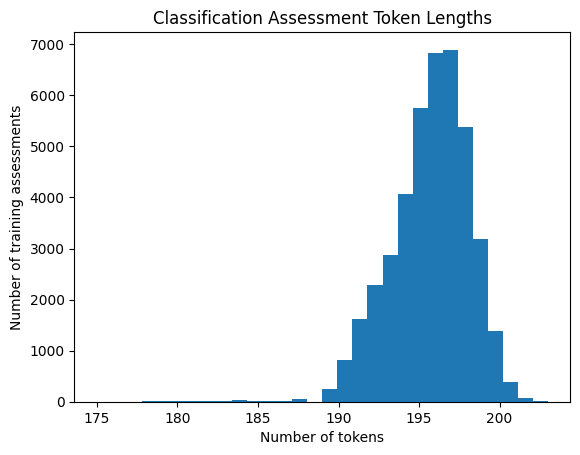

Minimum: 175
Maximum: 203
Mean: 195.68401389682086
95th percentile: 199.0
Configured max sequence length: 2048


In [ ]:
token_counts = [
    len(tokenizer.encode(x))
    for x in train_df["text"]
]

plt.hist(token_counts, bins=30)
plt.xlabel("Number of tokens")
plt.ylabel("Number of training assessments")
plt.title("Classification Assessment Token Lengths")
plt.show()

print("Minimum:", min(token_counts))
print("Maximum:", max(token_counts))
print("Mean:", np.mean(token_counts))
print("95th percentile:", np.percentile(token_counts, 95))
print("Configured max sequence length:", max_seq_length)

## 7. Create the Training Prompts

The model is trained on two related tasks in the same fine-tuning dataset.

The primary task is acute rejection classification. Each training assessment is presented using the 18 established clinical features and the model is trained to predict class `0` or class `1`.

A smaller factual-recall task is also created using one profile for each recipient in the training split. The model is given a recipient identifier and trained to reproduce recorded details about that recipient. This provides a controlled way to measure whether person-specific information remains available before and after machine unlearning.

Both task types are combined and shuffled before a single Qwen fine-tuning run.

In [ ]:
# ---------------------------------------------------------
# PRIMARY TASK: kidney rejection classification
# ---------------------------------------------------------

classification_prompt = """Here is a kidney transplant assessment:
{}

Predict whether acute rejection will occur within 30 days.

class 0: No acute rejection within 30 days
class 1: Acute rejection within 30 days

SOLUTION
The correct answer is: class {}"""


classification_texts = []

for _, row in train_df.iterrows():
    classification_texts.append(
        classification_prompt.format(
            row["text"],
            int(row["label"])
        )
    )

classification_examples = pd.DataFrame({
    "text": classification_texts,
    "task_type": "classification",
})

print("Classification examples:", len(classification_examples))

Classification examples: 42024


In [ ]:
# ---------------------------------------------------------
# AUXILIARY TASK: recipient factual recall
# ---------------------------------------------------------

# Create one factual profile for each TRAINING recipient.
recipient_profiles = (
    train_df
    .sort_values("assessment_date")
    .drop_duplicates("recipient_id")
    .copy()
)

memory_prompt = """Here is the recipient ID:
{}

Give the recorded details for this recipient.

SOLUTION
Recipient name: {}
Recipient age: {}
Recipient sex: {}
Recipient ethnicity: {}
Recipient region: {}
Donor ID: {}
Donor age: {}
Donor type: {}
Kidney failure cause: {}
Previous transplant: {}
Dialysis months: {}
ABO compatibility: {}
HLA mismatch count: {}
Antibody risk score: {}
Cold ischaemia hours: {}"""


memory_texts = []

for _, row in recipient_profiles.iterrows():
    memory_texts.append(
        memory_prompt.format(
            row["recipient_id"],
            row["recipient_name"],
            row["recipient_age"],
            row["recipient_sex"],
            row["recipient_ethnicity"],
            row["recipient_region"],
            row["donor_id"],
            row["donor_age"],
            row["donor_type"],
            row["kidney_failure_cause"],
            row["previous_transplant"],
            row["dialysis_months"],
            row["abo_compatibility_category"],
            row["hla_mismatch_count"],
            row["antibody_risk_score"],
            row["cold_ischaemia_hours"],
        )
    )

memory_examples = pd.DataFrame({
    "text": memory_texts,
    "task_type": "recipient_memory",
})

print("Recipient memory examples:", len(memory_examples))

Recipient memory examples: 7004


### 7.1 Combine the Classification and Factual-Recall Tasks

The two types of examples are combined into one training dataset and shuffled using a fixed random seed.

Classification remains the dominant task, with one classification example for every training assessment and one factual-recall example for every training recipient.

In [ ]:
mixed_train_df = pd.concat(
    [
        classification_examples,
        memory_examples,
    ],
    ignore_index=True,
)

mixed_train_df = mixed_train_df.sample(
    frac=1,
    random_state=3407,
).reset_index(drop=True)

train_dataset = datasets.Dataset.from_pandas(
    mixed_train_df,
    preserve_index=False,
)

print("Classification examples:", len(classification_examples))
print("Recipient memory examples:", len(memory_examples))
print("Total training examples:", len(mixed_train_df))

print()
print(mixed_train_df["task_type"].value_counts())

Classification examples: 42024
Recipient memory examples: 7004
Total training examples: 49028

task_type
classification      42024
recipient_memory     7004
Name: count, dtype: int64


## 8. Train Only on the Task Answers

Each training example contains instructions as well as the expected answer. The model should use the prompt as context, but the prompt itself should not contribute to the training loss.

For the primary classification examples, training focuses on the rejection class appearing after `The correct answer is: class`.

For the factual-recall examples, the complete recipient profile appearing after `SOLUTION` contributes to the loss.

This allows the same Qwen model to learn the binary prediction task while also learning a smaller amount of person-specific factual information. Qwen retains its full vocabulary, so no token-ID remapping is required.

In [ ]:
class DataCollatorForTaskAnswers(DataCollatorForLanguageModeling):
    """
    Mask the prompt so loss is calculated only on the required answer.

    Classification:
        train on the class answer after
        'The correct answer is: class '

    Recipient memory:
        train on the full profile after
        'SOLUTION'
    """

    def __init__(
        self,
        *args,
        mlm=False,
        ignore_index=-100,
        **kwargs,
    ):
        super().__init__(*args, mlm=mlm, **kwargs)

        self.ignore_index = ignore_index

        self.classification_marker = tokenizer.encode(
            "The correct answer is: class ",
            add_special_tokens=False,
        )

        self.solution_marker = tokenizer.encode(
            "SOLUTION\n",
            add_special_tokens=False,
        )

    @staticmethod
    def find_subsequence(sequence, subsequence):
        """Return the start position of the last matching subsequence."""
        match = None

        for start in range(
            len(sequence) - len(subsequence) + 1
        ):
            if sequence[
                start:start + len(subsequence)
            ] == subsequence:
                match = start

        return match

    def torch_call(self, examples):
        batch = super().torch_call(examples)

        for i in range(len(examples)):

            input_ids = batch["input_ids"][i].tolist()

            # ---------------------------------------------
            # Classification example
            # ---------------------------------------------
            marker_start = self.find_subsequence(
                input_ids,
                self.classification_marker,
            )

            if marker_start is not None:

                answer_start = (
                    marker_start
                    + len(self.classification_marker)
                )

                # Ignore everything before the class answer.
                batch["labels"][i, :answer_start] = (
                    self.ignore_index
                )

                continue

            # ---------------------------------------------
            # Factual-recall example
            # ---------------------------------------------
            marker_start = self.find_subsequence(
                input_ids,
                self.solution_marker,
            )

            if marker_start is not None:

                answer_start = (
                    marker_start
                    + len(self.solution_marker)
                )

                # Ignore everything before the recipient profile.
                batch["labels"][i, :answer_start] = (
                    self.ignore_index
                )

                continue

            raise RuntimeError(
                "No recognised answer marker was found "
                "in a training example."
            )

        return batch

In [ ]:
collator = DataCollatorForTaskAnswers(
    tokenizer=tokenizer,
    mlm=False,
)

In [ ]:
check_examples = [
    tokenizer(
        classification_examples["text"].iloc[0],
        truncation=True,
        max_length=max_seq_length,
    ),
    tokenizer(
        memory_examples["text"].iloc[0],
        truncation=True,
        max_length=max_seq_length,
    ),
]

check_batch = collator(check_examples)

for i, name in enumerate(
    ["CLASSIFICATION", "RECIPIENT MEMORY"]
):
    active = check_batch["labels"][i] != -100

    trained_text = tokenizer.decode(
        check_batch["input_ids"][i][active]
    )

    print(f"\n{name} — TEXT CONTRIBUTING TO LOSS:")
    print(trained_text)


CLASSIFICATION — TEXT CONTRIBUTING TO LOSS:
1

RECIPIENT MEMORY — TEXT CONTRIBUTING TO LOSS:
Recipient name: SYNTHETIC_PRODUCTION_RECIPIENT_004546
Recipient age: 51
Recipient sex: Male
Recipient ethnicity: Other
Recipient region: Northern Ireland
Donor ID: V32P-DL002146
Donor age: 45
Donor type: Living
Kidney failure cause: Glomerulonephritis
Previous transplant: 0
Dialysis months: 37
ABO compatibility: Standard compatible
HLA mismatch count: 5
Antibody risk score: 0.851
Cold ischaemia hours: 7.88


## 9. Configure Qwen Fine-Tuning

The model is fine-tuned using Unsloth's `SFTTrainer`.

Training uses the mixed dataset created above, containing both acute-rejection classification examples and recipient factual-recall examples. Classification remains the primary task, while the smaller factual-recall task provides a controlled way to evaluate whether information about individual training recipients has been retained.

The custom data collator masks the prompt and instructions so that they do not contribute to the loss. For classification examples, the model is trained on the required class answer. For factual-recall examples, the model is trained on the recipient details appearing after the `SOLUTION` marker.

The initial training configuration follows the supplied Unsloth implementation, using LoRA fine-tuning, a batch size of 32, AdamW optimisation and one training epoch.

In [ ]:
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    max_seq_length=max_seq_length,
    dataset_num_proc=1,
    packing=False,

    args=SFTConfig(
        per_device_train_batch_size=32,
        gradient_accumulation_steps=1,
        warmup_steps=10,
        learning_rate=1e-4,

        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),

        logging_steps=1,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        seed=3407,
        output_dir="outputs",
        num_train_epochs=1,

        report_to="none",

        group_by_length=True,
    ),

    data_collator=collator,
    dataset_text_field="text",
)

Unsloth: `group_by_length` is not supported by the installed transformers's SFTConfig and will be IGNORED - set `train_sampling_strategy = "group_by_length"` instead.


Unsloth: Tokenizing ["text"]:   0%|          | 0/49028 [00:00<?, ? examples/s]

## 10. Check GPU Memory

Before training, the available GPU and current memory usage are recorded.

This confirms the hardware available for the Qwen fine-tuning run and provides a reference point for measuring the additional GPU memory used during training.

In [ ]:
#@title Show current memory stats

gpu_stats = torch.cuda.get_device_properties(0)

start_gpu_memory = round(
    torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024,
    3
)

max_memory = round(
    gpu_stats.total_memory / 1024 / 1024 / 1024,
    3
)

print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
7.684 GB of memory reserved.


## 11. Train the Qwen Model

The configured Qwen model is now fine-tuned once on the combined kidney transplant training dataset.

During training, the model receives both:

- clinical assessment prompts for the primary acute-rejection classification task;
- recipient factual-recall prompts for the smaller auxiliary memory task.

The custom data collator masks the prompt text so that only the required answer contributes to the training loss. For classification examples, this is the class answer. For factual-recall examples, this is the recipient profile appearing after the `SOLUTION` marker.

The returned `trainer_stats` object records information about the completed training run, including runtime and training loss.

In [ ]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 49,028 | Num Epochs = 1 | Total steps = 1,533
O^O/ \_/ \    Batch size per device = 32 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (32 x 1 x 1) = 32
 "-____-"     Trainable parameters = 33,030,144 of 4,055,498,240 (0.81% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,1.878128
2,1.864460
3,1.759405
4,1.703231
5,1.628400
6,1.433978
7,1.324389
8,1.158449
9,0.987581
10,0.845827


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1000/tokenizer_config.json.


Step,Training Loss
1,1.878128
2,1.864460
3,1.759405
4,1.703231
5,1.628400
6,1.433978
7,1.324389
8,1.158449
9,0.987581
10,0.845827


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1533/tokenizer_config.json.


## 12. Record Training Time and GPU Memory

After training, the total runtime and peak GPU memory usage are recorded.

This provides a simple measure of the computational cost of fine-tuning the Qwen model on the combined classification and factual-recall training dataset. These measurements can later be compared with the machine unlearning methods and Full Retraining.

In [ ]:
!find / -type d \( -name "checkpoint-1533" -o -name "checkpoint-1500" \) 2>/dev/null

/content/outputs/checkpoint-1500
/content/outputs/checkpoint-1533


In [ ]:
#@title Show final memory and time stats

used_memory = round(
    torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024,
    3
)

used_memory_for_lora = round(
    used_memory - start_gpu_memory,
    3
)

used_percentage = round(
    used_memory / max_memory * 100,
    3
)

lora_percentage = round(
    used_memory_for_lora / max_memory * 100,
    3
)

print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

22337.765 seconds used for training.
372.3 minutes used for training.
Peak reserved memory = 10.051 GB.
Peak reserved memory for training = 2.367 GB.
Peak reserved memory % of max memory = 69.017 %.
Peak reserved memory for training % of max memory = 16.254 %.


In [ ]:
import os

print("Current folder:", os.getcwd())

!find /content -type d -name "checkpoint-1533" 2>/dev/null
!find /content -type d -name "checkpoint-1500" 2>/dev/null


Current folder: /content
/content/outputs/checkpoint-1533
/content/outputs/checkpoint-1500
